In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

In [5]:
# Ladataan data suoraan CSV-tiedostosta
csv_path = '../bytebuddies_dbt/seeds/osastot.csv'
df_osastot = pd.read_csv(csv_path)

df_osastot.head()

,osasto_id,nimi,alku_x,alku_y,loppu_x,loppu_y
0,1,Kassa ja poistuminen,0,0,800,5220
1,2,Sesonki ja torialue,1200,1800,2800,3800
2,3,Pukeutuminen,1000,0,4500,1800
3,4,Koti ja sisustus,4500,0,7500,2500
4,5,Teknokemia ja hygienia,2800,2800,5500,5220


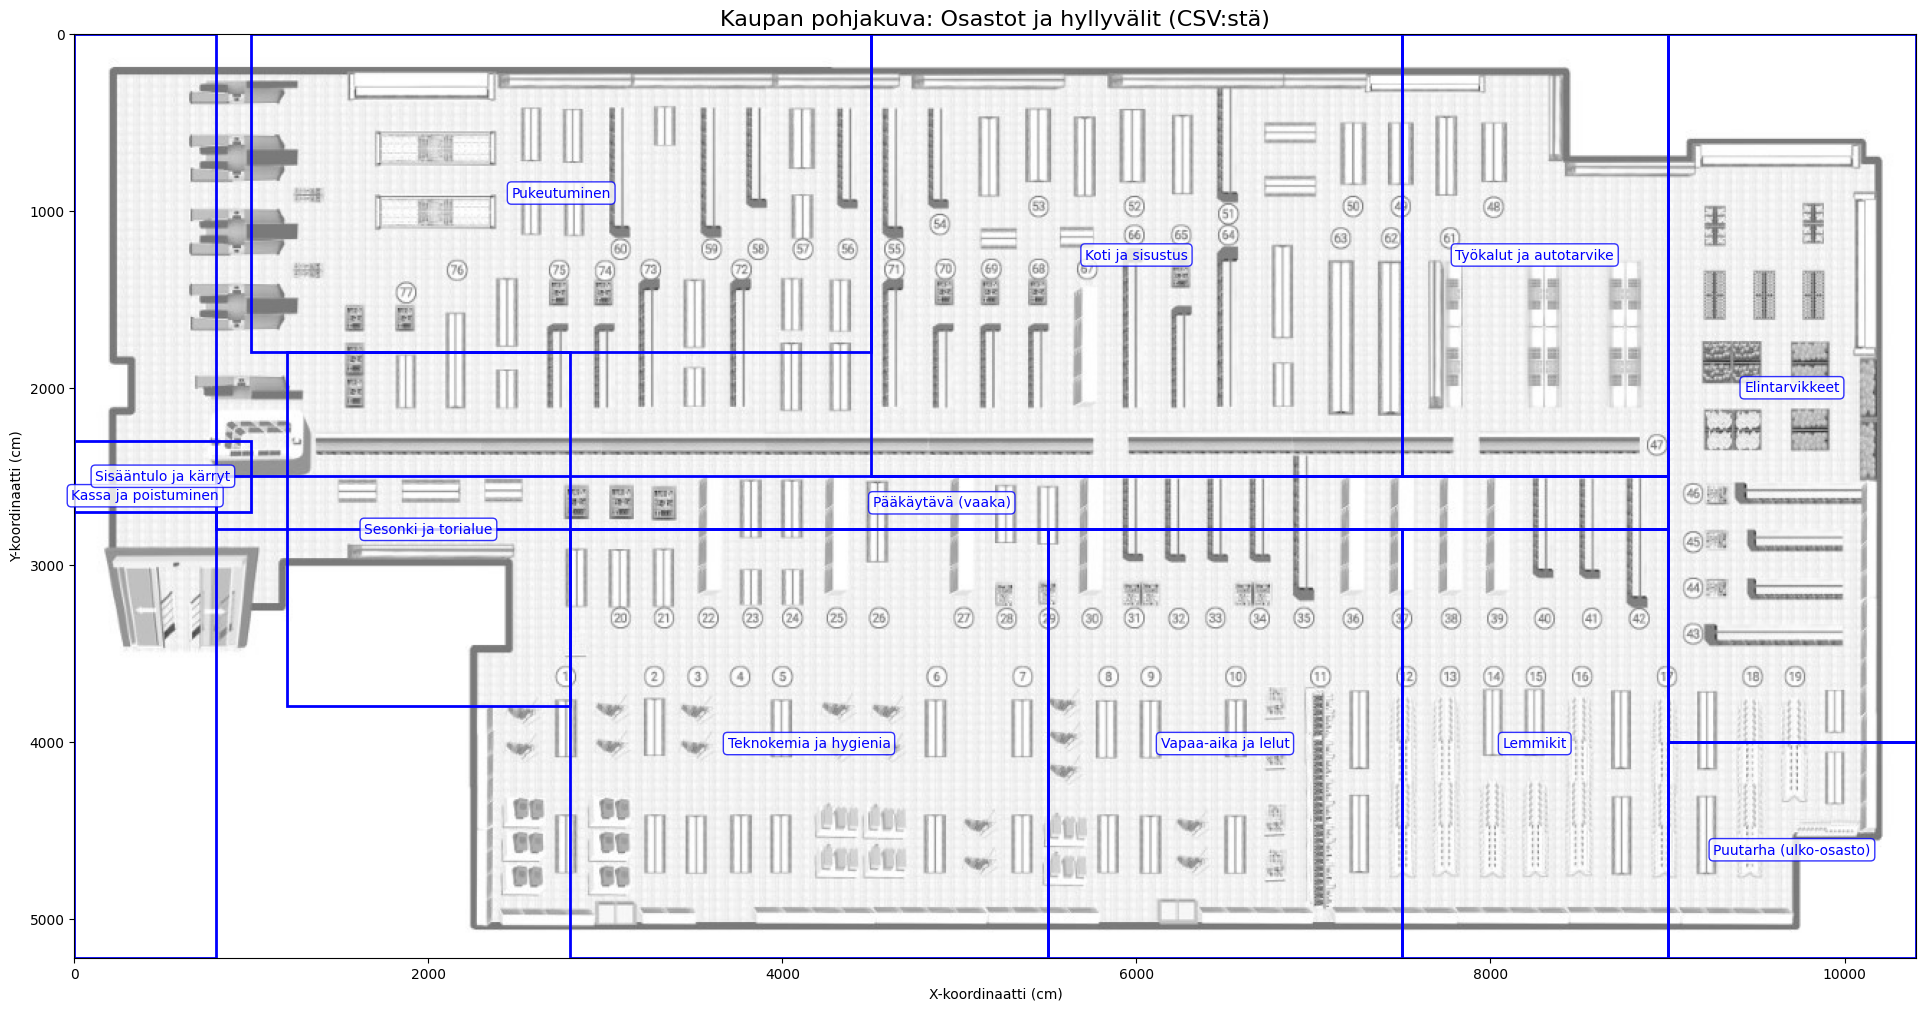

In [6]:
# Ladataan pohjakuva
img_path = '../image/kauppa.png'
img = mpimg.imread(img_path)

# Luodaan iso kuvaaja
fig, ax = plt.subplots(figsize=(24, 12))

# Näytetään kuva ja käännetään y-akseli oikein päin (y=0 ylhäällä)
ax.imshow(img, extent=[0, 10406, 5220, 0])

# Piirretään osastojen rajat (Rectangle)
for _, row in df_osastot.iterrows():
    width = row['loppu_x'] - row['alku_x']
    height = row['loppu_y'] - row['alku_y']
    rect = patches.Rectangle(
        (row['alku_x'], row['alku_y']), 
        width, height, 
        linewidth=2, 
        edgecolor='blue', 
        facecolor='none'
    )
    ax.add_patch(rect)
    
    # Lisätään osaston nimi laatikon keskelle
    ax.text(
        row['alku_x'] + width/2, 
        row['alku_y'] + height/2, 
        row['nimi'], 
        color='blue', 
        fontsize=10, 
        ha='center', 
        va='center',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue', boxstyle='round,pad=0.3')
    )

ax.set_title('Kaupan pohjakuva: Osastot ja hyllyvälit (CSV:stä)', fontsize=16)
ax.set_xlabel('X-koordinaatti (cm)')
ax.set_ylabel('Y-koordinaatti (cm)')

# Estetään koordinaatiston leikkaantuminen
plt.xlim(0, 10406)
plt.ylim(5220, 0)
plt.show()